# Loan Risk Descriptive & Predictive Analysis

This notebook makes use of the LendingClub sub data set for accepted loans from https://www.kaggle.com/datasets/wordsforthewise/lending-club/data and builds machine learning models to predict whether a loan will be fully paid or charged off.

The target variable is `loan_status`.

The project includes:

1. Data loading and cleaning
2. Descriptive analysis
3. Data visualization
4. Correlation heatmap
5. Cross-validation model comparison
6. Feature importance analysis

The classification target is:

- `0` = Fully Paid
- `1` = Charged Off

In [23]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Machine learning
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 1. Load the Dataset

The dataset is loaded from a local CSV file in the same folder as this notebook.

For this project, the local file is:

`accepted_loans_sample_db.csv`

Only selected variables are loaded to keep the analysis focused on loan default prediction.

In [24]:
# Local dataset path
path = "accepted_loans_sample_db.csv"

# Selected features
features = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low"
]

# Load selected columns
df = pd.read_csv(path, usecols=features)

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (500000, 12)


,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low
0,7200.0,36 months,7.99,A,9 years,MORTGAGE,202000.0,Source Verified,Charged Off,home_improvement,19.40,680.0
1,10000.0,36 months,7.90,A,9 years,MORTGAGE,37617.0,Verified,Fully Paid,credit_card,20.61,725.0
2,35000.0,36 months,7.89,A,4 years,MORTGAGE,200000.0,Source Verified,Fully Paid,other,14.95,680.0
3,5000.0,36 months,16.29,D,1 year,MORTGAGE,50000.0,Source Verified,Fully Paid,debt_consolidation,22.28,670.0
4,20000.0,36 months,18.25,E,3 years,RENT,65000.0,Verified,Fully Paid,debt_consolidation,10.65,660.0


In [25]:
# Basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            500000 non-null  float64
 1   term                 500000 non-null  str    
 2   int_rate             500000 non-null  float64
 3   grade                500000 non-null  str    
 4   emp_length           470699 non-null  str    
 5   home_ownership       500000 non-null  str    
 6   annual_inc           500000 non-null  float64
 7   verification_status  500000 non-null  str    
 8   loan_status          500000 non-null  str    
 9   purpose              500000 non-null  str    
 10  dti                  499851 non-null  float64
 11  fico_range_low       500000 non-null  float64
dtypes: float64(5), str(7)
memory usage: 45.8 MB


In [26]:
# Missing values before cleaning
df.isnull().sum()

loan_amnt                  0
term                       0
int_rate                   0
grade                      0
emp_length             29301
home_ownership             0
annual_inc                 0
verification_status        0
loan_status                0
purpose                    0
dti                      149
fico_range_low             0
dtype: int64

## 2. Data Cleaning

The model should only use loans with a final outcome.

Therefore, this notebook keeps only:

- `Fully Paid`
- `Charged Off`

Other loan statuses are removed because they do not represent a final repayment outcome.

In [27]:
# Drop missing values
df = df.dropna()

# Keep only final loan outcomes
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

print("Dataset shape after cleaning:", df.shape)
df["loan_status"].value_counts()

Dataset shape after cleaning: (470693, 12)


loan_status
Fully Paid     378760
Charged Off     91933
Name: count, dtype: int64

## 3. Feature Cleaning and Encoding

Several columns contain text values that need to be converted into numerical values.

The target variable is encoded as:

- `0` = Fully Paid
- `1` = Charged Off

The loan grade is encoded from A to G, where A is the strongest grade and G is the weakest grade.

Categorical variables such as `home_ownership` and `purpose` are transformed using one-hot encoding.

In [28]:
# Encode target variable
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

# Encode loan grade
grade_map = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}

df["grade"] = df["grade"].map(grade_map)

# Encode verification status
verify_map = {
    "Not Verified": 0,
    "Source Verified": 1,
    "Verified": 1
}

df["verification_status"] = df["verification_status"].map(verify_map)

df.head()

,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low
0,7200.0,36 months,7.99,1,9 years,MORTGAGE,202000.0,1,1,home_improvement,19.40,680.0
1,10000.0,36 months,7.90,1,9 years,MORTGAGE,37617.0,1,0,credit_card,20.61,725.0
2,35000.0,36 months,7.89,1,4 years,MORTGAGE,200000.0,1,0,other,14.95,680.0
3,5000.0,36 months,16.29,4,1 year,MORTGAGE,50000.0,1,0,debt_consolidation,22.28,670.0
4,20000.0,36 months,18.25,5,3 years,RENT,65000.0,1,0,debt_consolidation,10.65,660.0


In [29]:
# Clean term column
df["term"] = (
    df["term"]
    .astype(str)
    .str.replace(" months", "", regex=False)
    .str.strip()
    .astype(int)
)

# Clean employment length column
df["emp_length"] = (
    df["emp_length"]
    .astype(str)
    .str.replace("10+ years", "10", regex=False)
    .str.replace("< 1 year", "0", regex=False)
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
    .str.strip()
    .astype(int)
)

df.head()

,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,fico_range_low
0,7200.0,36,7.99,1,9,MORTGAGE,202000.0,1,1,home_improvement,19.40,680.0
1,10000.0,36,7.90,1,9,MORTGAGE,37617.0,1,0,credit_card,20.61,725.0
2,35000.0,36,7.89,1,4,MORTGAGE,200000.0,1,0,other,14.95,680.0
3,5000.0,36,16.29,4,1,MORTGAGE,50000.0,1,0,debt_consolidation,22.28,670.0
4,20000.0,36,18.25,5,3,RENT,65000.0,1,0,debt_consolidation,10.65,660.0


In [30]:
# One-hot encode categorical variables
df = pd.get_dummies(
    df,
    columns=["home_ownership", "purpose"],
    drop_first=False
)

# Convert boolean dummy variables to integers
df = df.astype(int)

print("Final cleaned dataset shape:", df.shape)
df.head()

Final cleaned dataset shape: (470693, 30)


,loan_amnt,term,int_rate,grade,emp_length,annual_inc,verification_status,loan_status,dti,fico_range_low,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
0,7200,36,7,1,9,202000,1,1,19,680,...,1,0,0,0,0,0,0,0,0,0
1,10000,36,7,1,9,37617,1,0,20,725,...,0,0,0,0,0,0,0,0,0,0
2,35000,36,7,1,4,200000,1,0,14,680,...,0,0,0,0,0,1,0,0,0,0
3,5000,36,16,4,1,50000,1,0,22,670,...,0,0,0,0,0,0,0,0,0,0
4,20000,36,18,5,3,65000,1,0,10,660,...,0,0,0,0,0,0,0,0,0,0


# Descriptive Analysis

Before building machine learning models, this section explores the dataset using summary statistics and visualizations.

The goal is to understand:

- The distribution of fully paid and charged-off loans
- The relationship between default status and loan characteristics
- The distribution of loan amount, interest rate, income, DTI, and FICO score
- Correlations between the main numerical variables

In [31]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,470693.0,14596.183393,8753.232025,500.0,8000.0,12000.0,20000.0,40000.0
term,470693.0,41.914989,10.342769,36.0,36.0,36.0,36.0,60.0
int_rate,470693.0,12.654461,4.757460,5.0,9.0,12.0,15.0,30.0
grade,470693.0,2.744502,1.297387,1.0,2.0,3.0,3.0,7.0
emp_length,470693.0,5.964280,3.689053,0.0,2.0,6.0,10.0,10.0
annual_inc,470693.0,77940.162106,73570.577889,600.0,48000.0,65000.0,92500.0,9550000.0
verification_status,470693.0,0.692708,0.461372,0.0,0.0,1.0,1.0,1.0
loan_status,470693.0,0.195314,0.396443,0.0,0.0,0.0,0.0,1.0
dti,470693.0,17.610447,9.438776,0.0,11.0,17.0,23.0,999.0
fico_range_low,470693.0,696.183585,31.759605,660.0,670.0,690.0,710.0,845.0


## Target Variable Distribution

This chart shows the balance between fully paid loans and charged-off loans.

A strong imbalance is common in loan default datasets because most loans are usually fully paid.

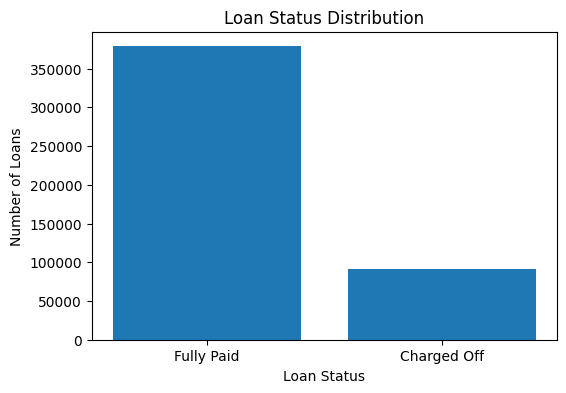

loan_status
0    378760
1     91933
Name: count, dtype: int64

In [32]:
status_counts = df["loan_status"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Fully Paid", "Charged Off"], status_counts.values)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

status_counts

## Loan Amount Distribution

This histogram shows the distribution of loan amounts.

It helps identify whether most loans are concentrated in lower, middle, or higher loan amount ranges.

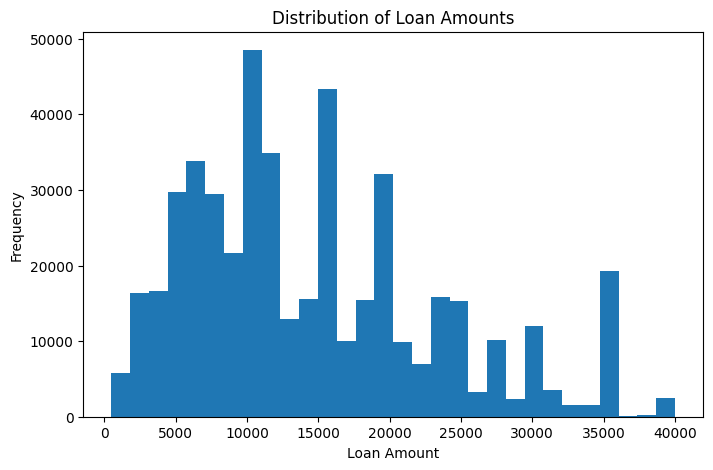

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df["loan_amnt"], bins=30)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

## Interest Rate Distribution by Loan Status

This chart compares interest rates between fully paid and charged-off loans.

Higher interest rates may be associated with higher perceived borrower risk.

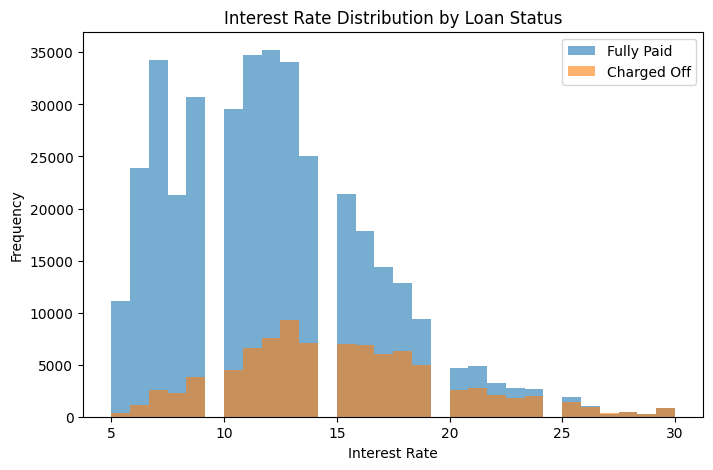

In [34]:
fully_paid_rates = df[df["loan_status"] == 0]["int_rate"]
charged_off_rates = df[df["loan_status"] == 1]["int_rate"]

plt.figure(figsize=(8, 5))
plt.hist(fully_paid_rates, bins=30, alpha=0.6, label="Fully Paid")
plt.hist(charged_off_rates, bins=30, alpha=0.6, label="Charged Off")
plt.title("Interest Rate Distribution by Loan Status")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Loan Grade and Default Rate

Loan grade is an important risk indicator.

This chart shows the average charged-off rate by grade.

Because `loan_status = 1` means charged off, the average value of `loan_status` represents the default rate.

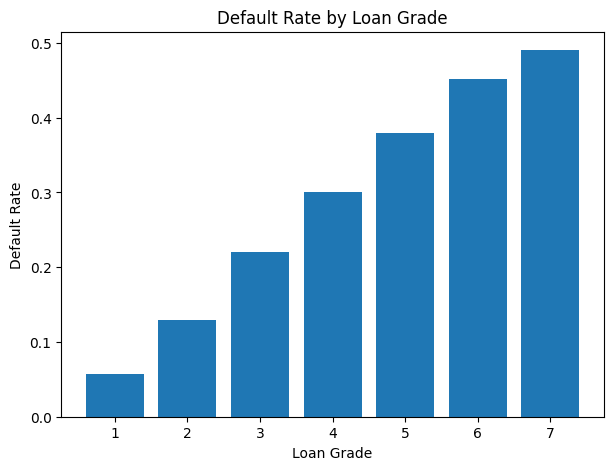

grade
1    0.057264
2    0.129300
3    0.219692
4    0.300047
5    0.379667
6    0.451504
7    0.490484
Name: loan_status, dtype: float64

In [35]:
grade_default_rate = df.groupby("grade")["loan_status"].mean()

plt.figure(figsize=(7, 5))
plt.bar(grade_default_rate.index.astype(str), grade_default_rate.values)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

grade_default_rate

## Debt-to-Income Ratio Distribution

The debt-to-income ratio, or DTI, compares a borrower's debt obligations to their income.

Higher DTI may indicate greater financial pressure.

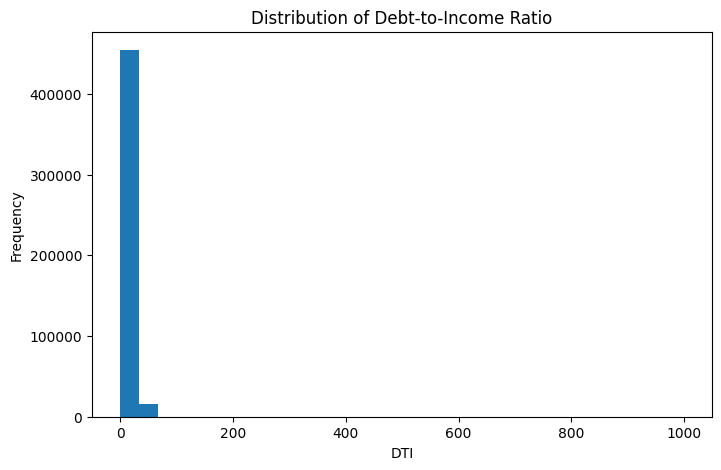

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(df["dti"], bins=30)
plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("DTI")
plt.ylabel("Frequency")
plt.show()

## FICO Score Distribution by Loan Status

FICO score is a common credit risk variable.

This chart compares FICO score distributions for fully paid and charged-off loans.

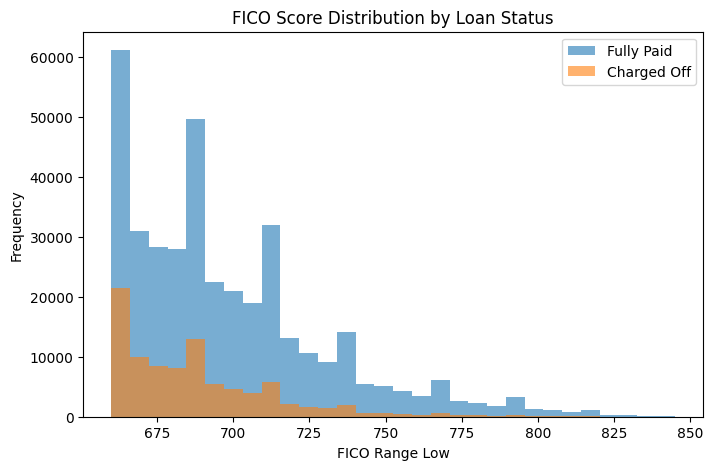

In [37]:
fully_paid_fico = df[df["loan_status"] == 0]["fico_range_low"]
charged_off_fico = df[df["loan_status"] == 1]["fico_range_low"]

plt.figure(figsize=(8, 5))
plt.hist(fully_paid_fico, bins=30, alpha=0.6, label="Fully Paid")
plt.hist(charged_off_fico, bins=30, alpha=0.6, label="Charged Off")
plt.title("FICO Score Distribution by Loan Status")
plt.xlabel("FICO Range Low")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Average Default Rate by Loan Purpose

This chart compares default rates across different loan purposes.

Because purpose was one-hot encoded, the original purpose columns now appear as `purpose_...`.

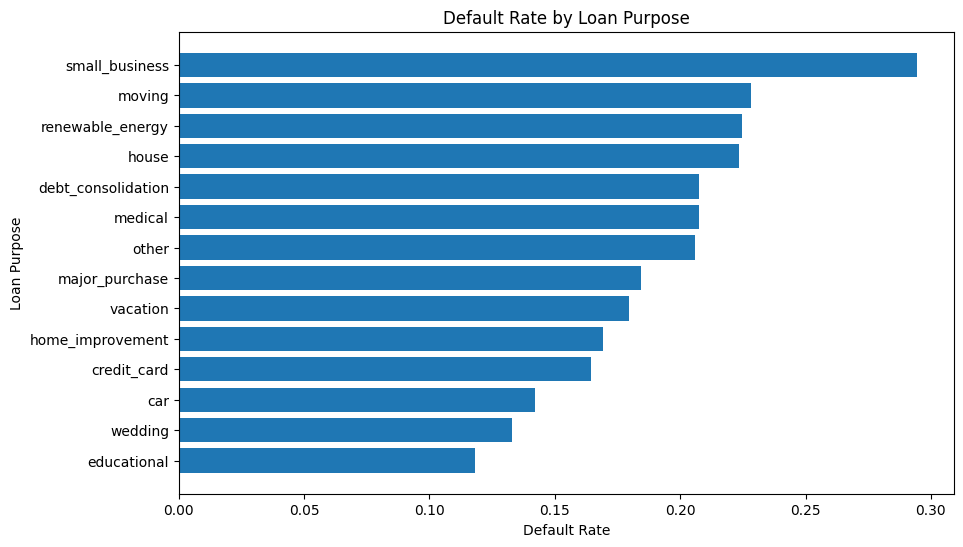

,Purpose,Default Rate
11,small_business,0.294393
8,moving,0.228113
10,renewable_energy,0.224551
5,house,0.223267
2,debt_consolidation,0.207676
7,medical,0.207501
9,other,0.205830
6,major_purchase,0.184540
12,vacation,0.179529
4,home_improvement,0.169169


In [38]:
purpose_columns = [col for col in df.columns if col.startswith("purpose_")]

purpose_default_rates = {}

for col in purpose_columns:
    purpose_name = col.replace("purpose_", "")
    purpose_default_rates[purpose_name] = df.loc[df[col] == 1, "loan_status"].mean()

purpose_default_df = pd.DataFrame({
    "Purpose": list(purpose_default_rates.keys()),
    "Default Rate": list(purpose_default_rates.values())
})

purpose_default_df = purpose_default_df.sort_values(
    by="Default Rate",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(purpose_default_df["Purpose"], purpose_default_df["Default Rate"])
plt.gca().invert_yaxis()
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate")
plt.ylabel("Loan Purpose")
plt.show()

purpose_default_df

## Correlation Heatmap

The heatmap shows the linear correlation between the main numeric variables.

The target variable is `loan_status`.

Since:

- `0` = Fully Paid
- `1` = Charged Off

A positive correlation with `loan_status` means the variable tends to increase when default risk increases.

Correlation does not prove causation, but it helps identify useful patterns before modeling.

In [39]:
correlation_columns = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "emp_length",
    "annual_inc",
    "verification_status",
    "dti",
    "fico_range_low"
]

corr_df = df[correlation_columns].corr()

corr_df

,loan_status,loan_amnt,term,int_rate,grade,emp_length,annual_inc,verification_status,dti,fico_range_low
loan_status,1.000000,0.071972,0.181585,0.260304,0.263746,-0.015108,-0.036245,0.088140,0.095533,-0.133285
loan_amnt,0.071972,1.000000,0.378801,0.147660,0.148583,0.089495,0.296943,0.223041,0.037228,0.101284
term,0.181585,0.378801,1.000000,0.423342,0.431970,0.054447,0.044188,0.138147,0.072770,-0.004398
int_rate,0.260304,0.147660,0.423342,1.000000,0.952327,-0.005360,-0.068984,0.220423,0.165472,-0.403737
grade,0.263746,0.148583,0.431970,0.952327,1.000000,-0.005676,-0.065817,0.220787,0.167038,-0.408305
emp_length,-0.015108,0.089495,0.054447,-0.005360,-0.005676,1.000000,0.064950,0.002867,0.028262,0.019925
annual_inc,-0.036245,0.296943,0.044188,-0.068984,-0.065817,0.064950,1.000000,0.067871,-0.152353,0.072196
verification_status,0.088140,0.223041,0.138147,0.220423,0.220787,0.002867,0.067871,1.000000,0.045286,-0.148828
dti,0.095533,0.037228,0.072770,0.165472,0.167038,0.028262,-0.152353,0.045286,1.000000,-0.071787
fico_range_low,-0.133285,0.101284,-0.004398,-0.403737,-0.408305,0.019925,0.072196,-0.148828,-0.071787,1.000000


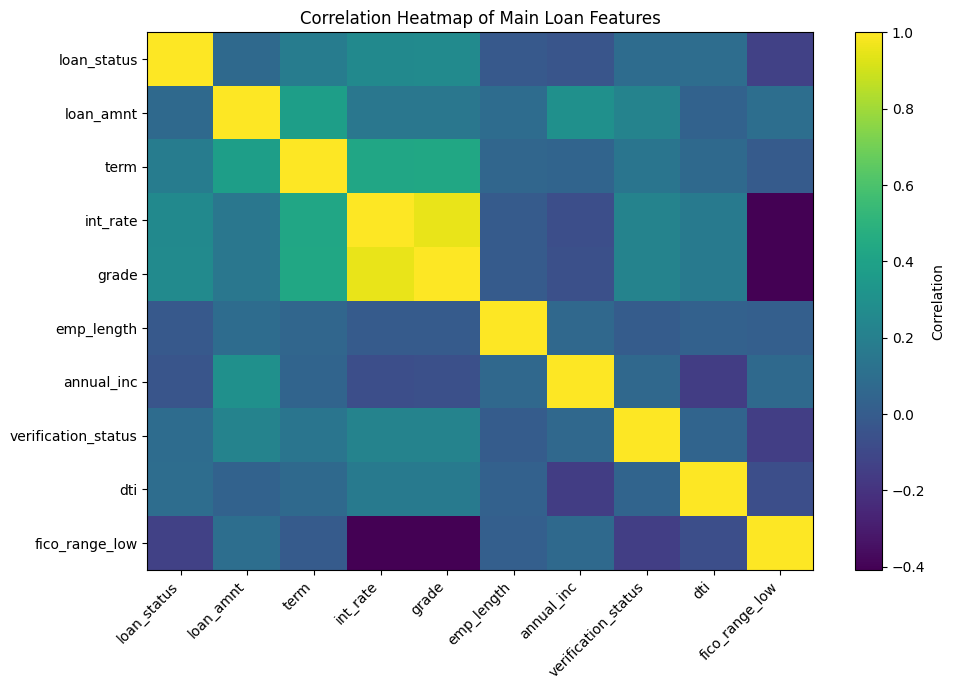

In [40]:
plt.figure(figsize=(10, 7))

plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

plt.title("Correlation Heatmap of Main Loan Features")
plt.tight_layout()
plt.show()

## Descriptive Analysis Summary

The descriptive analysis provides an initial understanding of the dataset before modeling.

The visualizations show:

- Whether the target variable is imbalanced
- How loan amount, interest rate, DTI, and FICO score are distributed
- How default rates vary by grade and loan purpose
- Which numerical variables are more strongly correlated with loan status

These insights help guide the machine learning stage, but the final model comparison should be based on cross-validation results.

# Predictive Modeling

The goal of the predictive modeling section is to compare several machine learning models for loan default prediction.

Only the following models are tested:

1. Random Forest
2. XGBoost
3. Logistic Regression
4. K-Nearest Neighbors

Instead of using a single 80/20 train-test split, this notebook uses 5-fold Stratified Cross-Validation.

This is more appropriate for a smaller dataset because each observation is used for both training and testing across different folds.

In [41]:
# Define features and target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

X shape: (470693, 29)
y shape: (470693,)

Target distribution:
loan_status
0    0.804686
1    0.195314
Name: proportion, dtype: float64


## Cross-Validation Strategy

Stratified K-Fold Cross-Validation is used to evaluate each model.

Stratification ensures that each fold keeps a similar proportion of fully paid and charged-off loans.

The metrics used are:

- Accuracy
- Precision for charged-off loans
- Recall for charged-off loans
- F1-score for charged-off loans

For this project, recall is especially important because it measures how many actual charged-off loans the model correctly identifies.

In [42]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_defaults": make_scorer(precision_score, zero_division=0),
    "recall_defaults": make_scorer(recall_score, zero_division=0),
    "f1_defaults": make_scorer(f1_score, zero_division=0)
}

print("Cross-validation strategy created.")
print("Number of folds:", cv.get_n_splits())

Cross-validation strategy created.
Number of folds: 5


## Model Selection

The notebook compares four models:

1. Random Forest
2. XGBoost
3. Logistic Regression
4. K-Nearest Neighbors

Logistic Regression and KNN are placed inside pipelines with `StandardScaler` because these models are sensitive to feature scale.

Tree-based models such as Random Forest and XGBoost do not require feature scaling.

XGBoost is included as a more advanced boosting model. It builds trees sequentially, where each new tree attempts to correct errors made by previous trees.

In [43]:
# XGBoost handles class imbalance using scale_pos_weight.
# Formula: number of negative cases / number of positive cases

negative_class = y.value_counts()[0]  # Fully Paid
positive_class = y.value_counts()[1]  # Charged Off

scale_pos_weight = negative_class / positive_class

print("Negative class count:", negative_class)
print("Positive class count:", positive_class)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Negative class count: 378760
Positive class count: 91933
scale_pos_weight: 4.12


In [44]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "K-Nearest Neighbors": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

print("Models ready for cross-validation:")
for model_name in models.keys():
    print("-", model_name)

Models ready for cross-validation:
- Random Forest
- XGBoost
- Logistic Regression
- K-Nearest Neighbors


## Cross-Validation Model Comparison

Each model is evaluated using the same 5-fold cross-validation strategy.

The results are stored in a summary table.

The model ranking is sorted by recall for charged-off loans.

In [50]:
results = []

for model_name, model in models.items():
    print(f"Evaluating: {model_name}")

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "Model": model_name,
        "Accuracy Mean": cv_results["test_accuracy"].mean(),
        "Accuracy Std": cv_results["test_accuracy"].std(),
        "Precision Defaults Mean": cv_results["test_precision_defaults"].mean(),
        "Precision Defaults Std": cv_results["test_precision_defaults"].std(),
        "Recall Defaults Mean": cv_results["test_recall_defaults"].mean(),
        "Recall Defaults Std": cv_results["test_recall_defaults"].std(),
        "F1 Defaults Mean": cv_results["test_f1_defaults"].mean(),
        "F1 Defaults Std": cv_results["test_f1_defaults"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Recall Defaults Mean",
    ascending=False
)

results_df

Evaluating: Random Forest
Evaluating: XGBoost
Evaluating: Logistic Regression
Evaluating: K-Nearest Neighbors


,Model,Accuracy Mean,Accuracy Std,Precision Defaults Mean,Precision Defaults Std,Recall Defaults Mean,Recall Defaults Std,F1 Defaults Mean,F1 Defaults Std
1,XGBoost,0.640373,0.001578,0.308481,0.001003,0.677504,0.002835,0.423933,0.001079
0,Random Forest,0.638221,0.001196,0.306748,0.000427,0.676417,0.003573,0.422082,0.000696
2,Logistic Regression,0.659253,0.001180,0.315462,0.001140,0.636431,0.002241,0.421831,0.001379
3,K-Nearest Neighbors,0.778361,0.000861,0.357025,0.003954,0.168275,0.002877,0.228729,0.003189


In [46]:
results_percent = results_df.copy()

percentage_columns = [
    "Accuracy Mean",
    "Accuracy Std",
    "Precision Defaults Mean",
    "Precision Defaults Std",
    "Recall Defaults Mean",
    "Recall Defaults Std",
    "F1 Defaults Mean",
    "F1 Defaults Std"
]

for col in percentage_columns:
    results_percent[col] = (results_percent[col] * 100).round(2)

results_percent

,Model,Accuracy Mean,Accuracy Std,Precision Defaults Mean,Precision Defaults Std,Recall Defaults Mean,Recall Defaults Std,F1 Defaults Mean,F1 Defaults Std
1,XGBoost,64.04,0.16,30.85,0.10,67.75,0.28,42.39,0.11
0,Random Forest,63.82,0.12,30.67,0.04,67.64,0.36,42.21,0.07
2,Logistic Regression,65.93,0.12,31.55,0.11,63.64,0.22,42.18,0.14
3,K-Nearest Neighbors,77.84,0.09,35.70,0.40,16.83,0.29,22.87,0.32


## Model Performance Visualization

The next chart compares model performance using recall for charged-off loans.

Recall is important in this project because the cost of missing a risky loan can be significant.

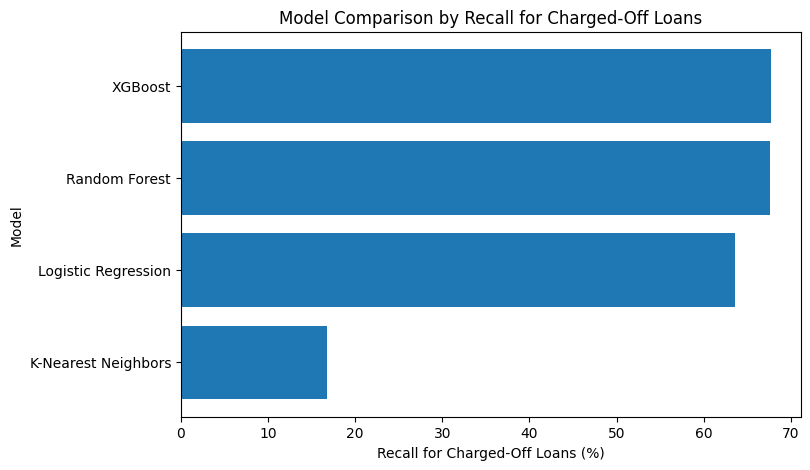

In [47]:
plt.figure(figsize=(8, 5))
plt.barh(results_percent["Model"], results_percent["Recall Defaults Mean"])
plt.gca().invert_yaxis()
plt.title("Model Comparison by Recall for Charged-Off Loans")
plt.xlabel("Recall for Charged-Off Loans (%)")
plt.ylabel("Model")
plt.show()

## Feature Importance

After comparing the models with cross-validation, a final Random Forest model is trained on the full dataset.

This final model is used only for interpretation, not for reporting cross-validation performance.

The goal is to identify which variables are most influential in predicting loan default risk.

In [48]:
final_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X, y)

importances = final_rf_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_df

,Feature,Importance
3,grade,0.318264
2,int_rate,0.253511
1,term,0.132428
8,fico_range_low,0.074099
7,dti,0.051746
0,loan_amnt,0.042232
5,annual_inc,0.031487
6,verification_status,0.028560
10,home_ownership_MORTGAGE,0.021236
14,home_ownership_RENT,0.018503


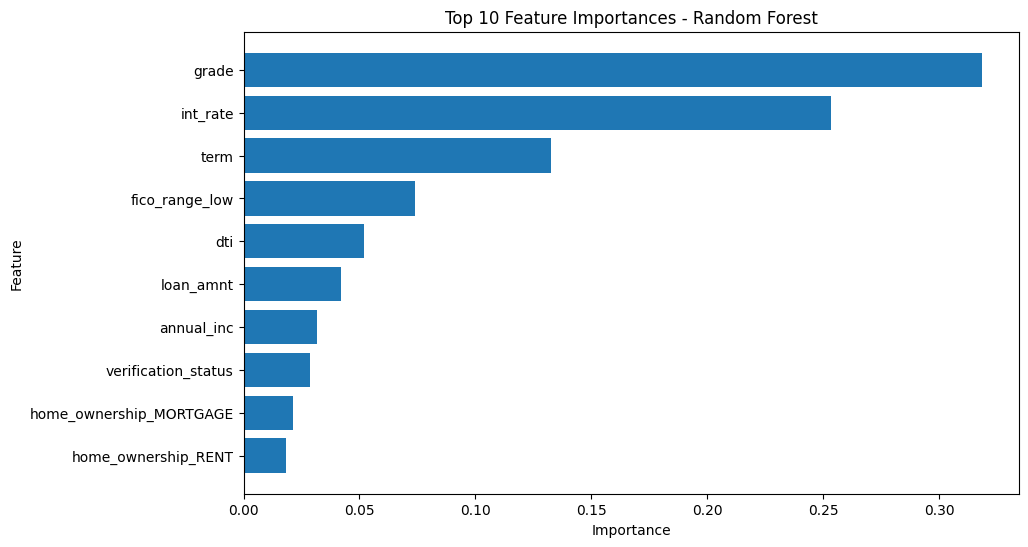

In [49]:
plt.figure(figsize=(10, 6))
plt.barh(feature_df["Feature"], feature_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Final Model Comparison

The final model comparison is based on 5-fold Stratified Cross-Validation.

The models were compared using:

- Accuracy
- Precision for charged-off loans
- Recall for charged-off loans
- F1-score for charged-off loans

The most appropriate model depends on the business objective.

For loan default prediction, recall is especially important because it measures how well the model identifies actual charged-off loans.

# Conclusion

This notebook developed a loan default prediction workflow using descriptive analysis, visualization, and machine learning.

The project first cleaned and transformed the dataset, then explored the data using visualizations such as:

- Loan status distribution
- Loan amount distribution
- Interest rate distribution by loan status
- Default rate by grade
- DTI distribution
- FICO score distribution by loan status
- Default rate by loan purpose
- Correlation heatmap

For predictive modeling, the notebook tested four models:

1. Random Forest
2. XGBoost
3. Logistic Regression
4. K-Nearest Neighbors

Instead of using a single 80/20 train-test split, the project used 5-fold Stratified Cross-Validation. This approach is more suitable for a smaller dataset because the models are evaluated across multiple train-test folds.

The final model comparison focused on accuracy, precision, recall, and F1-score for charged-off loans.

Because the project goal is to identify default risk, recall for charged-off loans is especially important.

A final Random Forest model was also trained on the full dataset to identify the most important features influencing default prediction.

Formal hyperparameter tuning was not performed in this version. Future work could improve the models using GridSearchCV or RandomizedSearchCV.